In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Global Superstore.csv to Global Superstore.csv


In [ ]:
import os

print(os.listdir('/content'))

['.config', 'Global Superstore.csv', 'sample_data']


In [ ]:
import pandas as pd

df = pd.read_csv("/content/Global Superstore.csv", encoding="latin1")

df.head()

,Category,City,Country,Customer ID,Customer Name,Discount,Market,ji_lu-shu,Order Date,Order ID,...,Sales,Segment,Ship Date,Ship Mode,Shipping Cost,State,Sub-Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,00:00.0,CA-2011-130813,...,19,Consumer,00:00.0,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,00:00.0,CA-2011-148614,...,19,Consumer,00:00.0,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,21,Consumer,00:00.0,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,111,Consumer,00:00.0,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,00:00.0,CA-2011-146969,...,6,Consumer,00:00.0,Standard Class,1.32,California,Paper,2011,North America,40


In [ ]:
df.shape

(51290, 27)

# Phase 2: Data Cleaning

This is one of the most important parts of any data analytics project. A clean dataset leads to accurate analysis and dashboards

In [ ]:
df.isnull().sum()

,0
Category,0
City,0
Country,0
Customer ID,0
Customer Name,0
Discount,0
Market,0
ji_lu-shu,0
Order Date,0
Order ID,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  object 
 1   City            51290 non-null  object 
 2   Country         51290 non-null  object 
 3   Customer ID     51290 non-null  object 
 4   Customer Name   51290 non-null  object 
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  object 
 7   ji_lu-shu       51290 non-null  int64  
 8   Order Date      51290 non-null  object 
 9   Order ID        51290 non-null  object 
 10  Order Priority  51290 non-null  object 
 11  Product ID      51290 non-null  object 
 12  Product Name    51290 non-null  object 
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  object 
 16  Row ID          51290 non-null  int64  
 17  Sales           51290 non-null 

In [ ]:
df['Order Date']=pd.to_datetime(df['Order Date'])
df['Ship Date']=pd.to_datetime(df['Ship Date'])

In [ ]:
df[['Order Date','Ship Date']].dtypes

,0
Order Date,datetime64[ns]
Ship Date,datetime64[ns]


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Category        51290 non-null  object        
 1   City            51290 non-null  object        
 2   Country         51290 non-null  object        
 3   Customer ID     51290 non-null  object        
 4   Customer Name   51290 non-null  object        
 5   Discount        51290 non-null  float64       
 6   Market          51290 non-null  object        
 7   ji_lu-shu       51290 non-null  int64         
 8   Order Date      51290 non-null  datetime64[ns]
 9   Order ID        51290 non-null  object        
 10  Order Priority  51290 non-null  object        
 11  Product ID      51290 non-null  object        
 12  Product Name    51290 non-null  object        
 13  Profit          51290 non-null  float64       
 14  Quantity        51290 non-null  int64         
 15  Re

Step 2: Create New Features

# These columns are very useful for analysis.

In [ ]:
df['Order Year']=df['Order Date'].dt.year
df['Order Month']=df['Order Date'].dt.month_name()
df['Order Quarter']=df['Order Date'].dt.quarter
df['Order Day']=df['Order Date'].dt.day_name()
df['Delivery Days']=(df['Ship Date']-df['Order Date']).dt.days
df['Profit Margin']=(df['Profit']/df['Sales'])*100


In [ ]:
df.head()
#You should now see six new columns at the end.

,Category,City,Country,Customer ID,Customer Name,Discount,Market,ji_lu-shu,Order Date,Order ID,...,Sub-Category,Year,Market2,weeknum,Order Year,Order Month,Order Quarter,Order Day,Delivery Days,Profit Margin
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2026-08-04,CA-2011-130813,...,Paper,2011,North America,2,2026,August,3,Tuesday,0,49.111579
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2026-08-04,CA-2011-148614,...,Paper,2011,North America,4,2026,August,3,Tuesday,0,48.909474
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2026-08-04,CA-2011-118962,...,Paper,2011,North America,32,2026,August,3,Tuesday,0,46.865714
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2026-08-04,CA-2011-118962,...,Paper,2011,North America,32,2026,August,3,Tuesday,0,47.982703
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2026-08-04,CA-2011-146969,...,Paper,2011,North America,40,2026,August,3,Tuesday,0,51.840000


In [ ]:
df.to_csv('cleaned_Global_Superstore.csv', index=False)
#Save the Cleaned Dataset

# 🚀 Phase 3: Exploratory Data Analysis (EDA)

Now comes the exciting part.

We're not going to randomly create charts. We'll answer real business questions.

In [ ]:
#What is the total sales, total profit, and total orders?
total_sales=df['Sales'].sum()
total_profit=df['Profit'].sum()
total_orders=df['Order ID'].nunique()

print("Total Sales:",total_sales)
print("Total Profit",round(total_profit,2))
print("Total Orders:",total_orders)

Total Sales: 12642905
Total Profit 1467457.29
Total Orders: 25035


In [ ]:
#Which category generates the highest sales?
category_sales=df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(category_sales)

Category
Technology         4744691
Furniture          4110884
Office Supplies    3787330
Name: Sales, dtype: int64


In [ ]:
#Which category earns the highest profit?
category_profit=df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
print(category_profit)

Category
Technology         663778.73318
Office Supplies    518473.83430
Furniture          285204.72380
Name: Profit, dtype: float64


In [ ]:
#Which region has the highest sales?
region_sales=df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
print(region_sales)

Region
Central           2822399
South             1600960
North             1248192
Oceania           1100207
Southeast Asia     884438
North Asia         848349
EMEA               806184
Africa             783776
Central Asia       752839
West               725514
East               678834
Caribbean          324281
Canada              66932
Name: Sales, dtype: int64


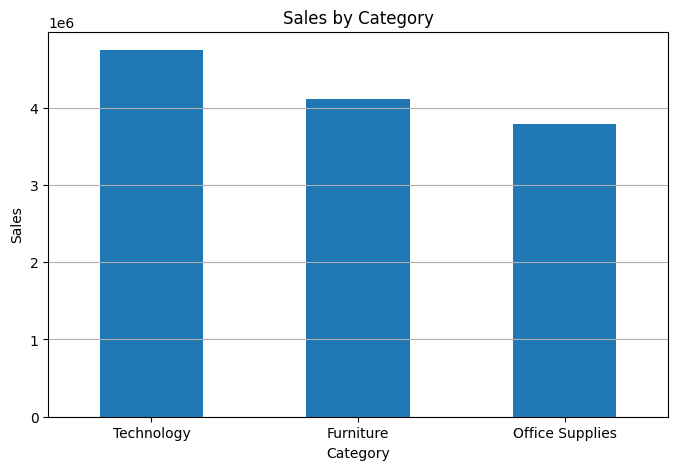

In [ ]:
plt.figure(figsize=(8,5))

category_sales.plot(kind='bar')

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.grid(axis='y')

plt.show()

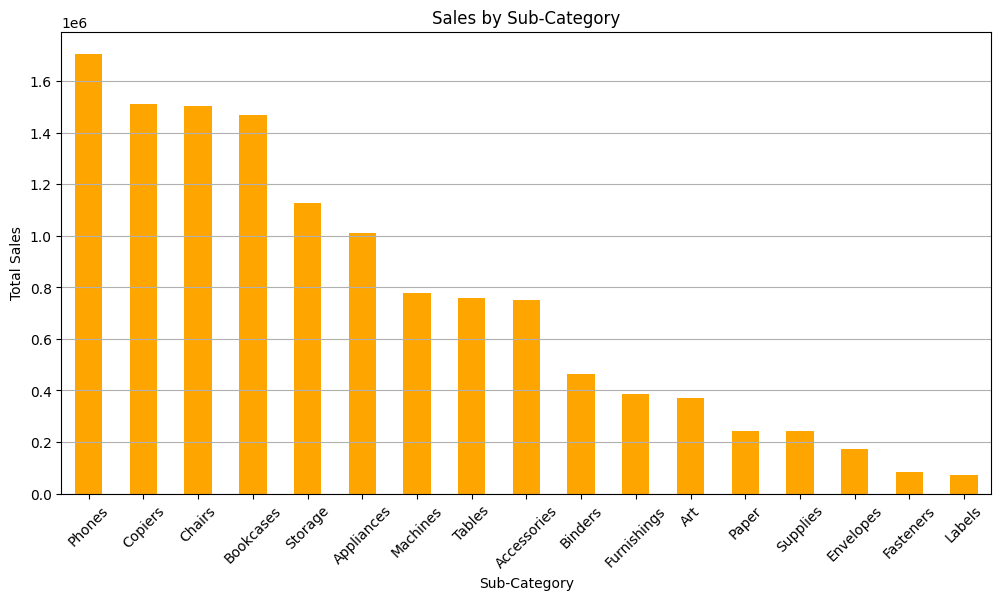

In [ ]:
#Question 2: Which Sub-Category Generates the Highest Sales?

subcategory_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
subcategory_sales.plot(kind='bar', color='orange')

plt.title("Sales by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

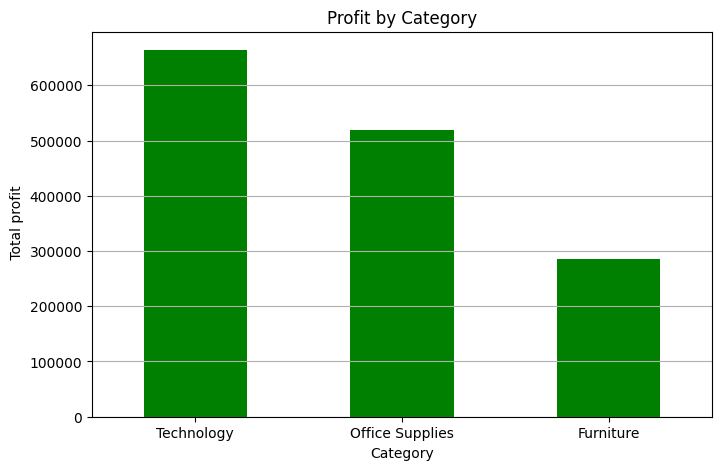

In [ ]:
#Question 3: Which Category Earns the Highest Profit?

category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_profit.plot(kind='bar',color='green')

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel(" Total profit")
plt.xticks(rotation=0)
plt.grid(axis='y')

plt.show()


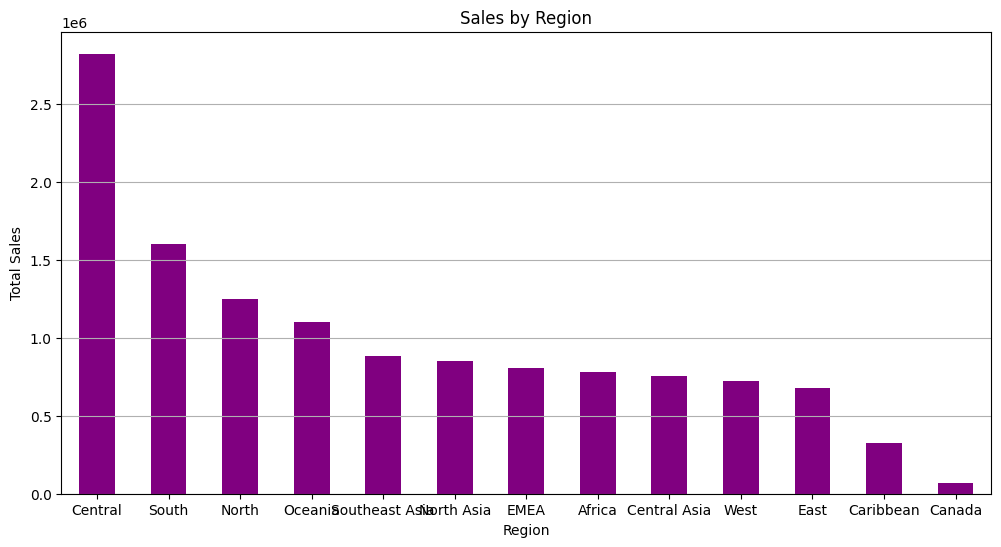

In [ ]:
#Question 4: Which Region Has the Highest Sales?
region_sales=df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
region_sales.plot(kind='bar',color='purple')
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.grid(axis='y')

plt.show()

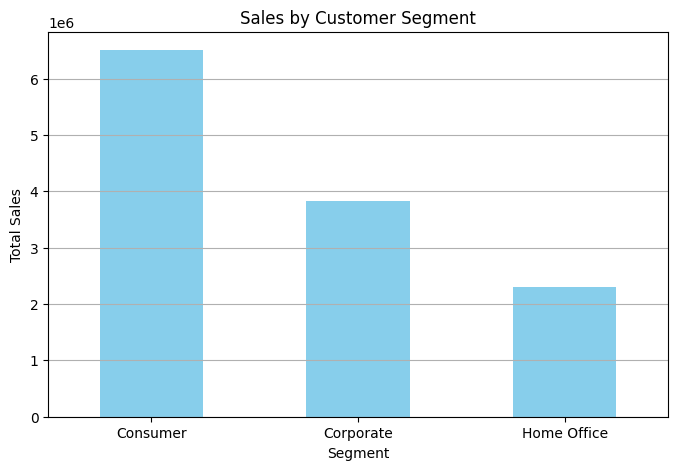

In [ ]:
# Question 5: Which Customer Segment Generates the Highest Sales?
segment_sales=df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
segment_sales.plot(kind='bar',color='skyblue')

plt.title("Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.grid(axis='y')

plt.show()


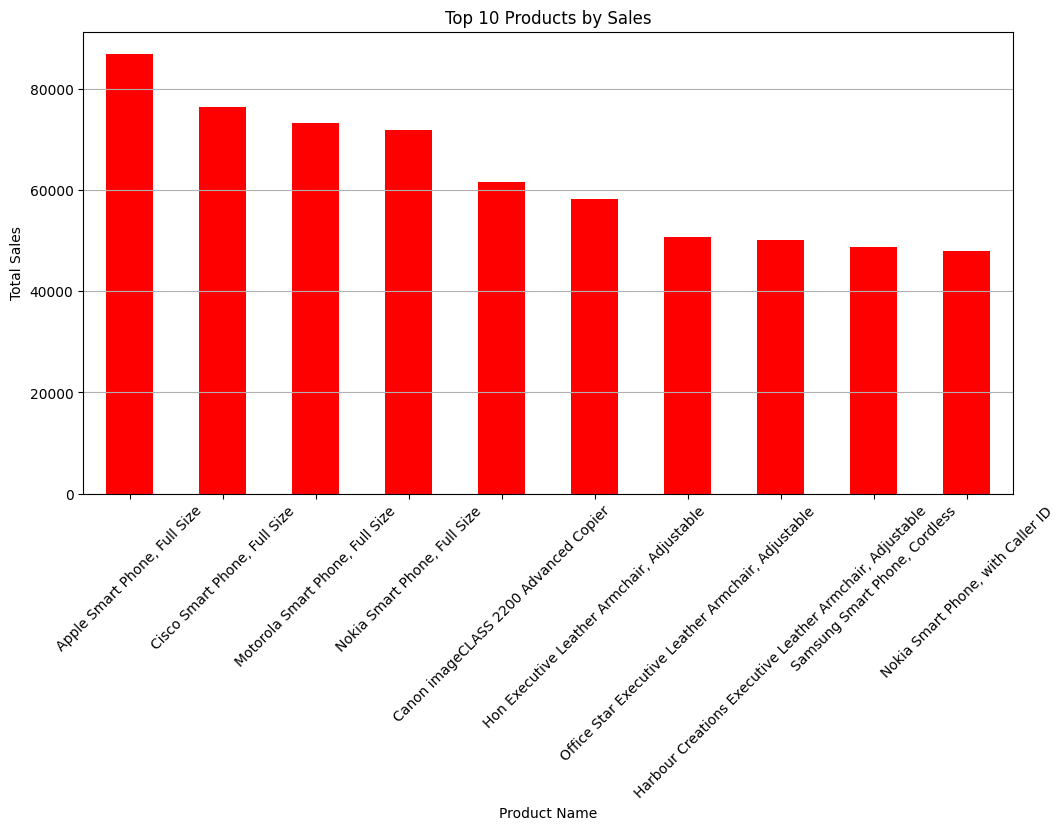

In [ ]:
#📊 Business Question 6: Top 10 Products by Sales

top_products=df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_products.plot(kind='bar', color='red')

plt.title("Top 10 Products by Sales")
plt.xlabel("Product Name")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()


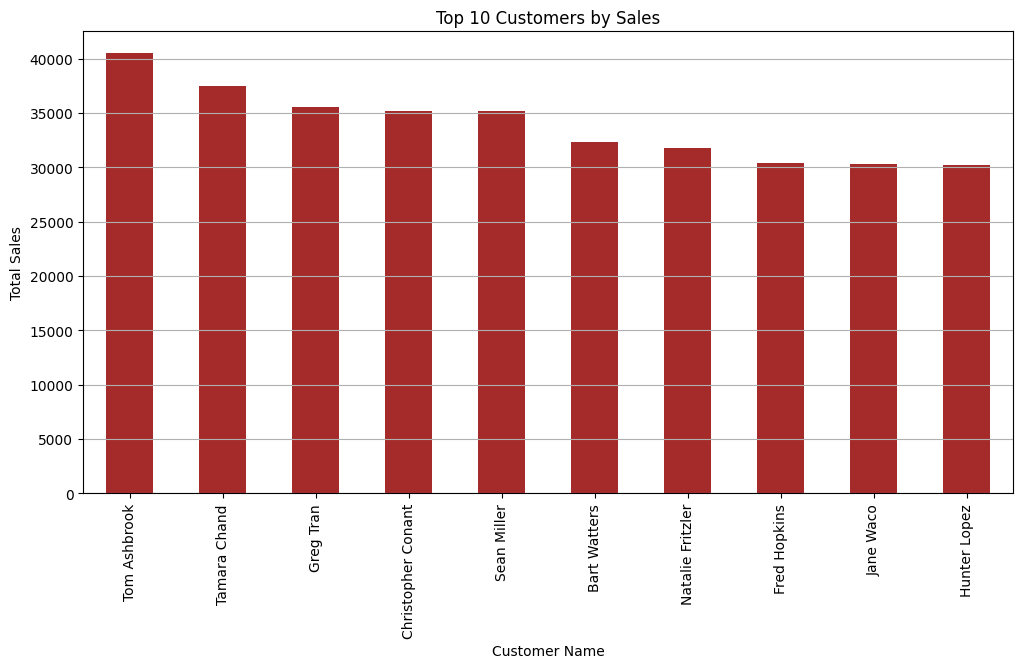

In [ ]:
#Question 7: Top 10 Customers by Sales

top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_customers.plot(kind='bar', color='brown')

plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer Name")
plt.ylabel("Total Sales")
plt.xticks(rotation=90)
plt.grid(axis='y')

plt.show()

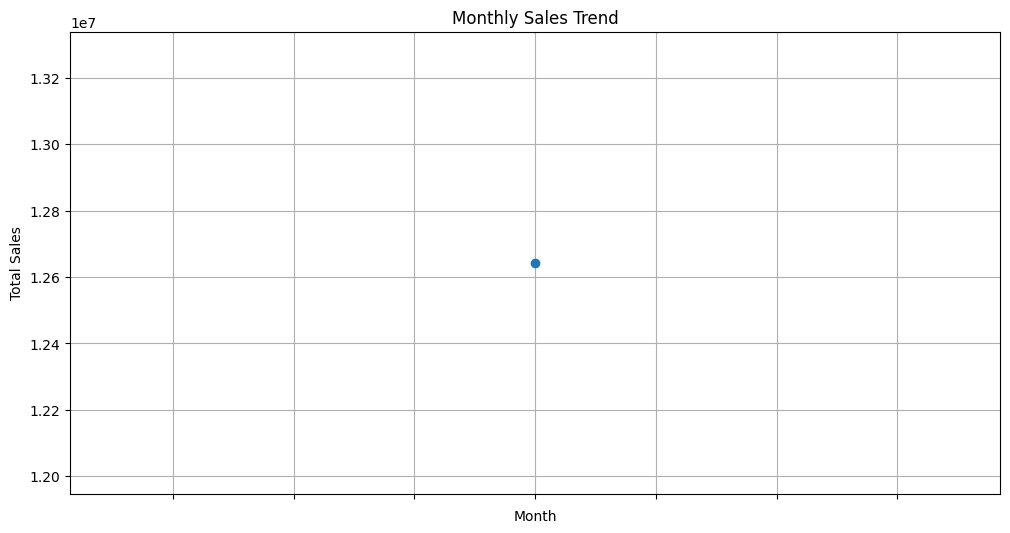

In [ ]:
#Question 8: How do Sales change over time?
#Monthly Sales Trend

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly_sales = df.groupby('Order Month')['Sales'].sum()
monthly_sales = monthly_sales.reindex(month_order)

plt.figure(figsize=(12,6))
monthly_sales.plot(marker='o', linewidth=3)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)

plt.show()

In [ ]:
monthly_profit = df.groupby('Order Month')['Profit'].sum()
monthly_profit = monthly_profit.reindex(month_order)

plt.figure(figsize=(12,6))
monthly_profit.plot(marker='o', linewidth=3, color='green')

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Total Profit")
plt.grid(True)

plt.show()

NameError: name 'df' is not defined

In [ ]:
df

NameError: name 'df' is not defined

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Global Superstore.csv to Global Superstore.csv


In [ ]:
df = pd.read_csv("Global Superstore.csv", encoding="latin1")
df.head()

,Category,City,Country,Customer ID,Customer Name,Discount,Market,ji_lu-shu,Order Date,Order ID,...,Sales,Segment,Ship Date,Ship Mode,Shipping Cost,State,Sub-Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,00:00.0,CA-2011-130813,...,19,Consumer,00:00.0,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,00:00.0,CA-2011-148614,...,19,Consumer,00:00.0,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,21,Consumer,00:00.0,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,111,Consumer,00:00.0,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,00:00.0,CA-2011-146969,...,6,Consumer,00:00.0,Standard Class,1.32,California,Paper,2011,North America,40


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

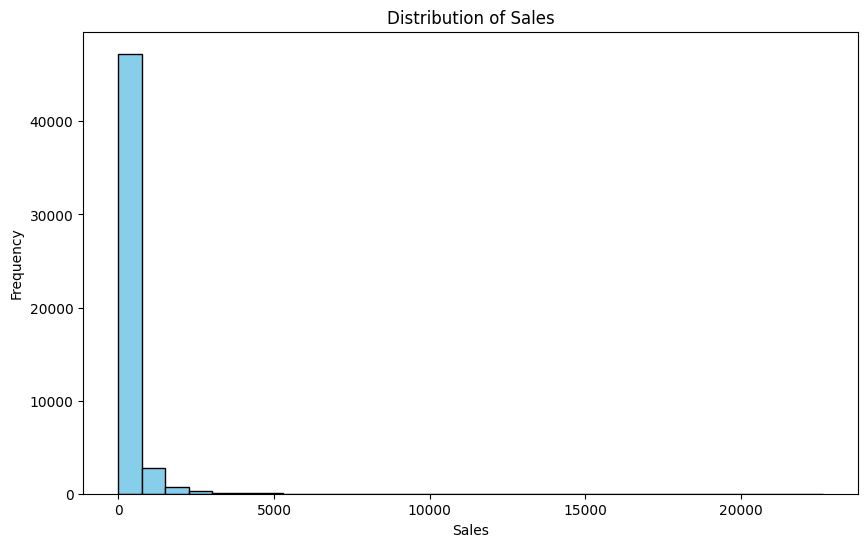

In [ ]:
#Business Question 10: Sales Distribution (Histogram)

plt.figure(figsize=(10,6))

plt.hist(df['Sales'], bins=30, color='skyblue', edgecolor='black')

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

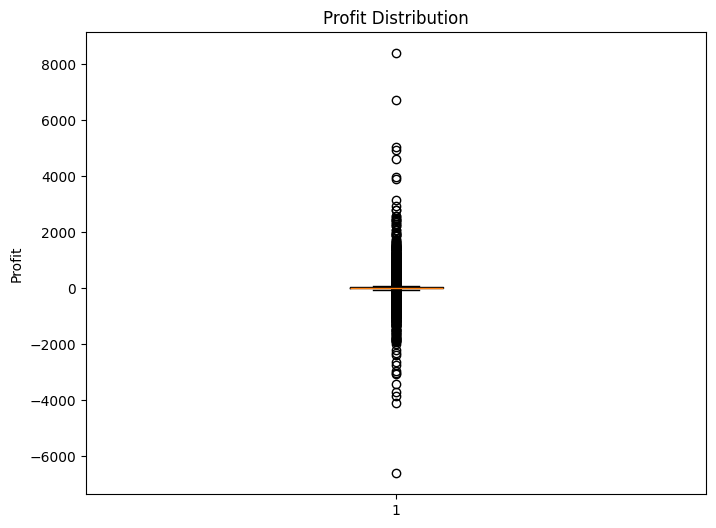

In [ ]:
#Question 11: Profit Distribution (Box Plot)

plt.figure(figsize=(8,6))

plt.boxplot(df['Profit'])

plt.title("Profit Distribution")
plt.ylabel("Profit")

plt.show()

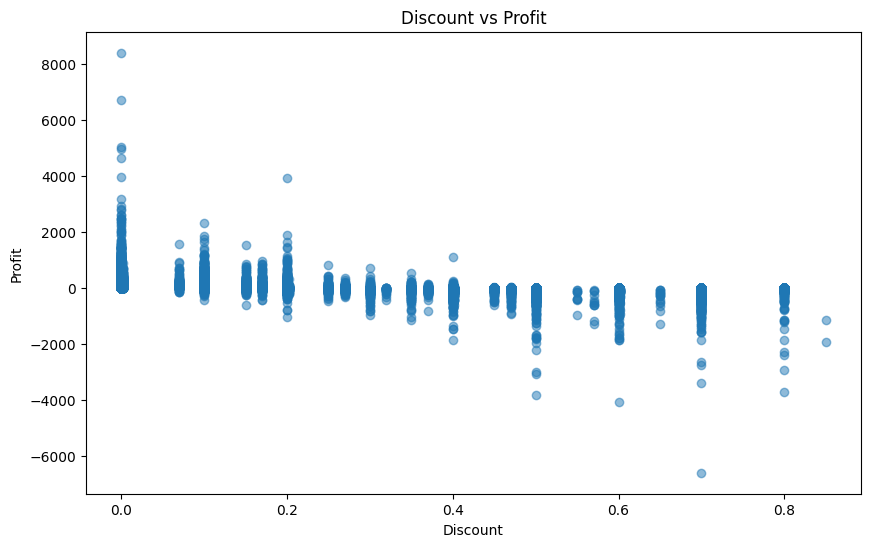

In [ ]:
#Question 12: Discount vs Profit

plt.figure(figsize=(10,6))
plt.scatter(df['Discount'],df['Profit'],alpha=0.5)
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

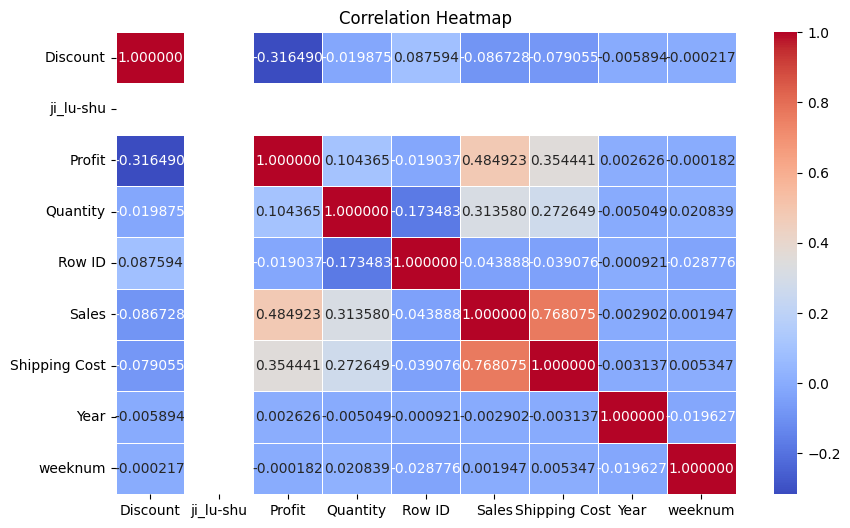

In [ ]:
#Question 13: Correlation Heatmap (Seaborn)

numeric_columns=df.select_dtypes(include=['int64','float64'])
correlation=numeric_columns.corr()

plt.figure(figsize=(10,6))
sns.heatmap(correlation,annot=True,cmap='coolwarm',fmt='2f',linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

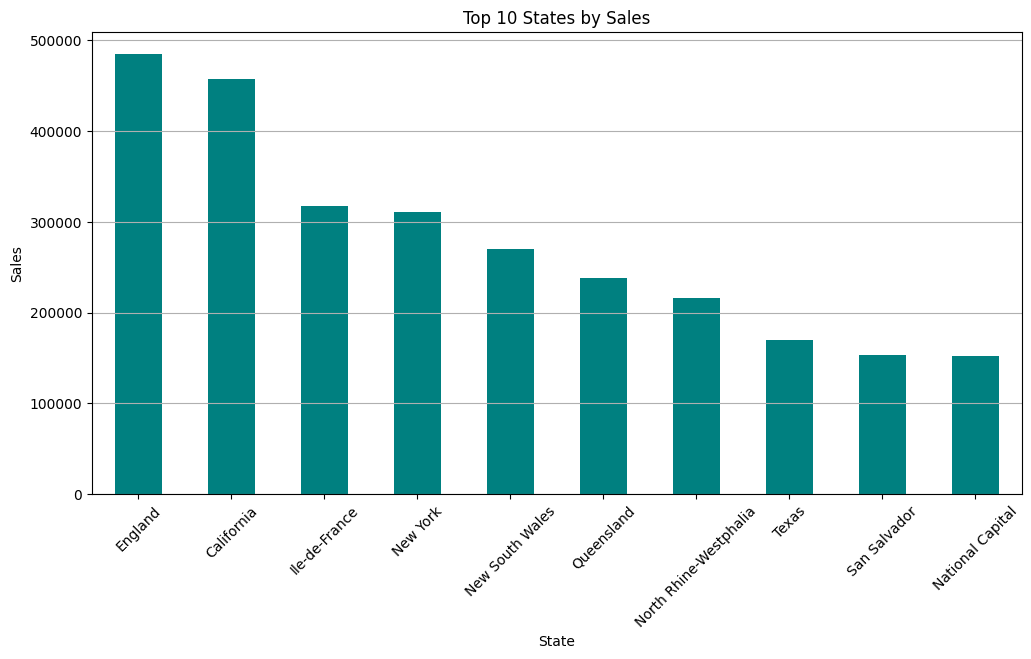

In [ ]:
#Question 14: Top 10 States by Sales

top_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

top_states.plot(kind='bar', color='teal')

plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Sales")

plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

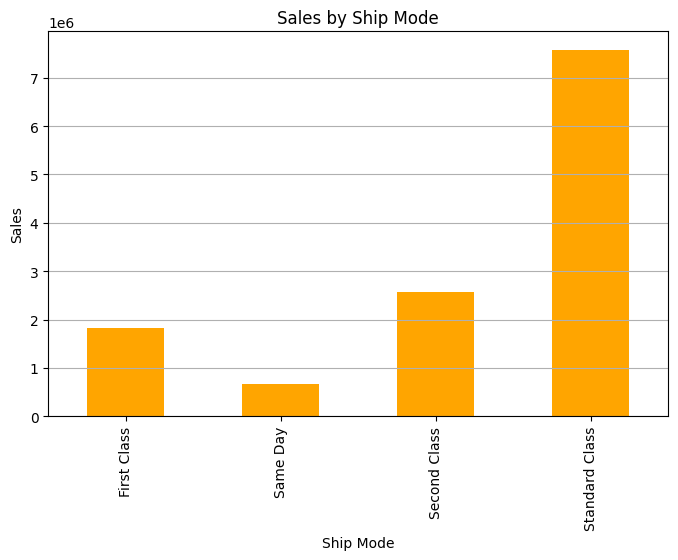

In [ ]:
#Question 15: Sales by Ship Mode

shipmode_sales = df.groupby('Ship Mode')['Sales'].sum()

plt.figure(figsize=(8,5))

shipmode_sales.plot(kind='bar', color='orange')

plt.title("Sales by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Sales")

plt.grid(axis='y')

plt.show()

In [ ]:
print(df.columns)

Index(['Category', 'City', 'Country', 'Customer ID', 'Customer Name',
       'Discount', 'Market', 'ji_lu-shu', 'Order Date', 'Order ID',
       'Order Priority', 'Product ID', 'Product Name', 'Profit', 'Quantity',
       'Region', 'Row ID', 'Sales', 'Segment', 'Ship Date', 'Ship Mode',
       'Shipping Cost', 'State', 'Sub-Category', 'Year', 'Market2', 'weeknum'],
      dtype='object')


In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [ ]:
# Extract Year
df['Order Year'] = df['Order Date'].dt.year

# Extract Month
df['Order Month'] = df['Order Date'].dt.month_name()

# Extract Quarter
df['Order Quarter'] = df['Order Date'].dt.quarter

# Extract Day
df['Order Day'] = df['Order Date'].dt.day_name()

# Delivery Days
df['Delivery Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# Profit Margin
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100

In [ ]:
df.columns.tolist()

['Category',
 'City',
 'Country',
 'Customer ID',
 'Customer Name',
 'Discount',
 'Market',
 'ji_lu-shu',
 'Order Date',
 'Order ID',
 'Order Priority',
 'Product ID',
 'Product Name',
 'Profit',
 'Quantity',
 'Region',
 'Row ID',
 'Sales',
 'Segment',
 'Ship Date',
 'Ship Mode',
 'Shipping Cost',
 'State',
 'Sub-Category',
 'Year',
 'Market2',
 'weeknum',
 'Order Year',
 'Order Month',
 'Order Quarter',
 'Order Day',
 'Delivery Days',
 'Profit Margin']

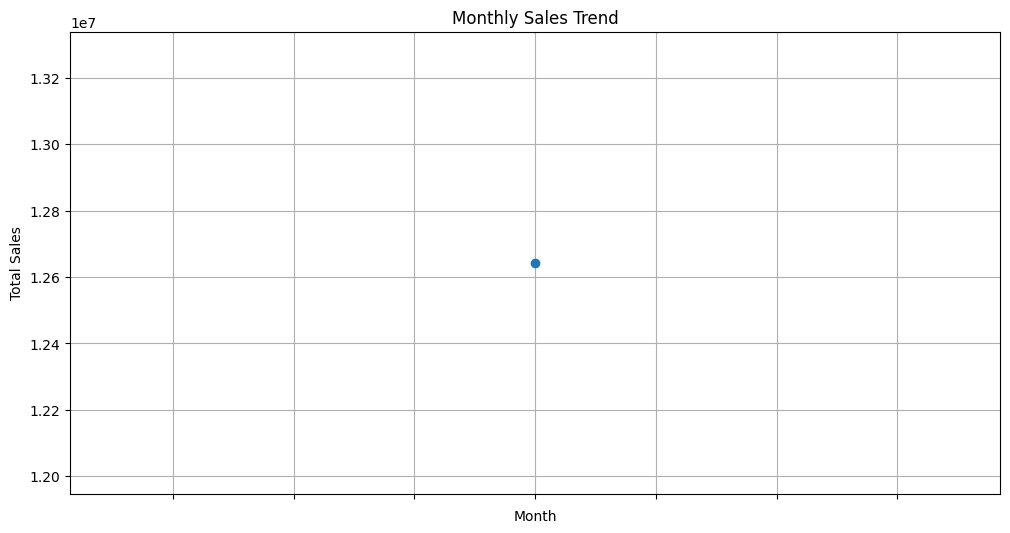

In [ ]:
#Which Month Generates the Highest Sales?

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly_sales = df.groupby('Order Month')['Sales'].sum()
monthly_sales = monthly_sales.reindex(month_order)

plt.figure(figsize=(12,6))

monthly_sales.plot(marker='o', linewidth=3)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.grid(True)

plt.show()


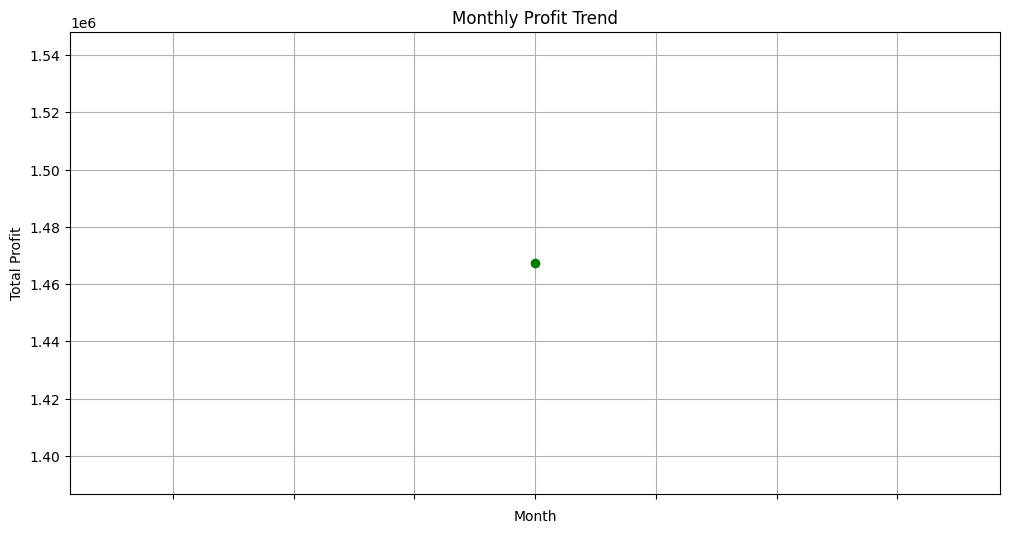

In [ ]:
#Which Month Earns the Highest Profit?

monthly_profit = df.groupby('Order Month')['Profit'].sum()
monthly_profit = monthly_profit.reindex(month_order)

plt.figure(figsize=(12,6))

monthly_profit.plot(marker='o', linewidth=3,color='green')

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Total Profit")

plt.grid(True)

plt.show()


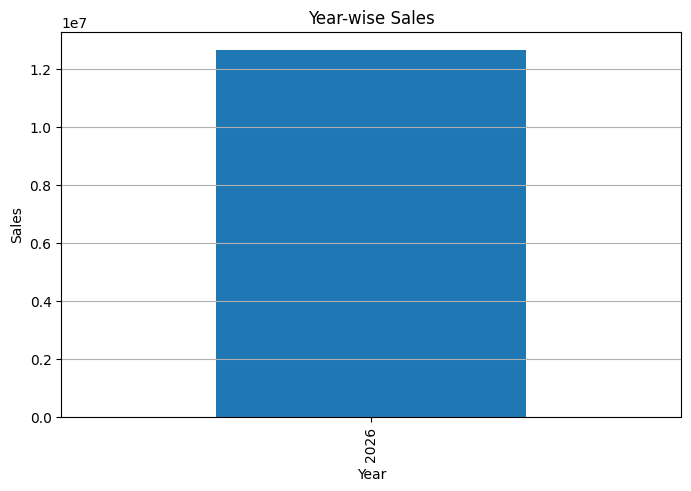

In [ ]:
#Which Year Has the Highest Sales?

year_sales = df.groupby('Order Year')['Sales'].sum()

plt.figure(figsize=(8,5))

year_sales.plot(kind='bar')

plt.title("Year-wise Sales")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.grid(axis='y')

plt.show()

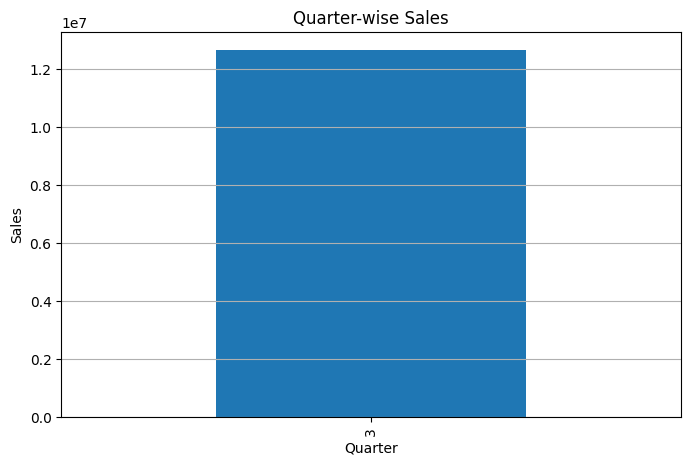

In [ ]:
#Which Quarter Performs Best?

quarter_sales = df.groupby('Order Quarter')['Sales'].sum()

plt.figure(figsize=(8,5))

quarter_sales.plot(kind='bar')

plt.title("Quarter-wise Sales")
plt.xlabel("Quarter")
plt.ylabel("Sales")

plt.grid(axis='y')

plt.show()




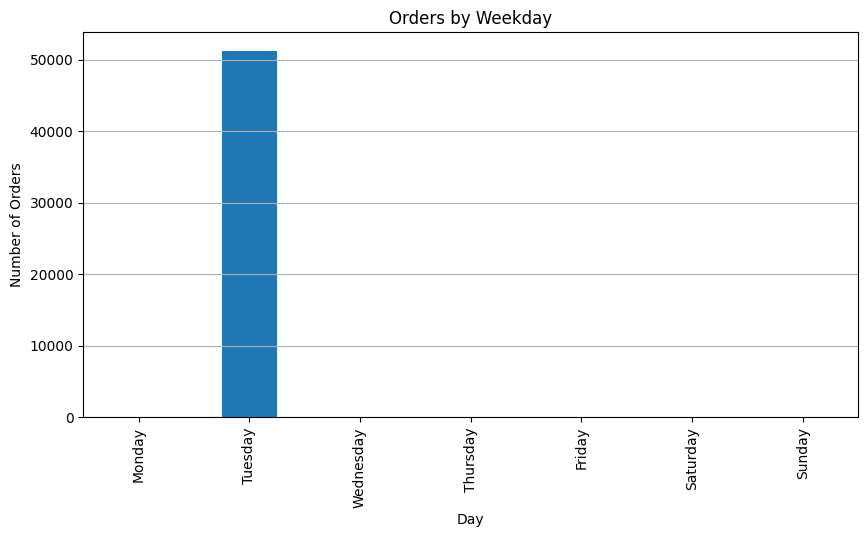

In [ ]:
#Which Weekday Receives Maximum Orders?

day_order = ['Monday','Tuesday','Wednesday','Thursday',
             'Friday','Saturday','Sunday']

orders_day = df.groupby('Order Day')['Order ID'].count()
orders_day = orders_day.reindex(day_order)

plt.figure(figsize=(10,5))

orders_day.plot(kind='bar')

plt.title("Orders by Weekday")
plt.xlabel("Day")
plt.ylabel("Number of Orders")

plt.grid(axis='y')

plt.show()


In [ ]:
average_delivery = df['Delivery Days'].mean()

print("Average Delivery Time:", round(average_delivery,2),"Days")

Average Delivery Time: 0.0 Days


📌 Analysis 1: Pareto Analysis (80/20 Rule)
Business Question

Which 20% of products generate 80% of the total sales?

This is used by companies like Amazon, Walmart, and Flipkart to identify their most valuable products.

In [ ]:
pareto = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False)

pareto = pareto.reset_index()
pareto.columns = ['Product Name', 'Sales']


In [ ]:
pareto['Cumulative Sales'] = pareto['Sales'].cumsum()
pareto['Cumulative Percentage'] = (
    pareto['Cumulative Sales'] / pareto['Sales'].sum()
) * 100

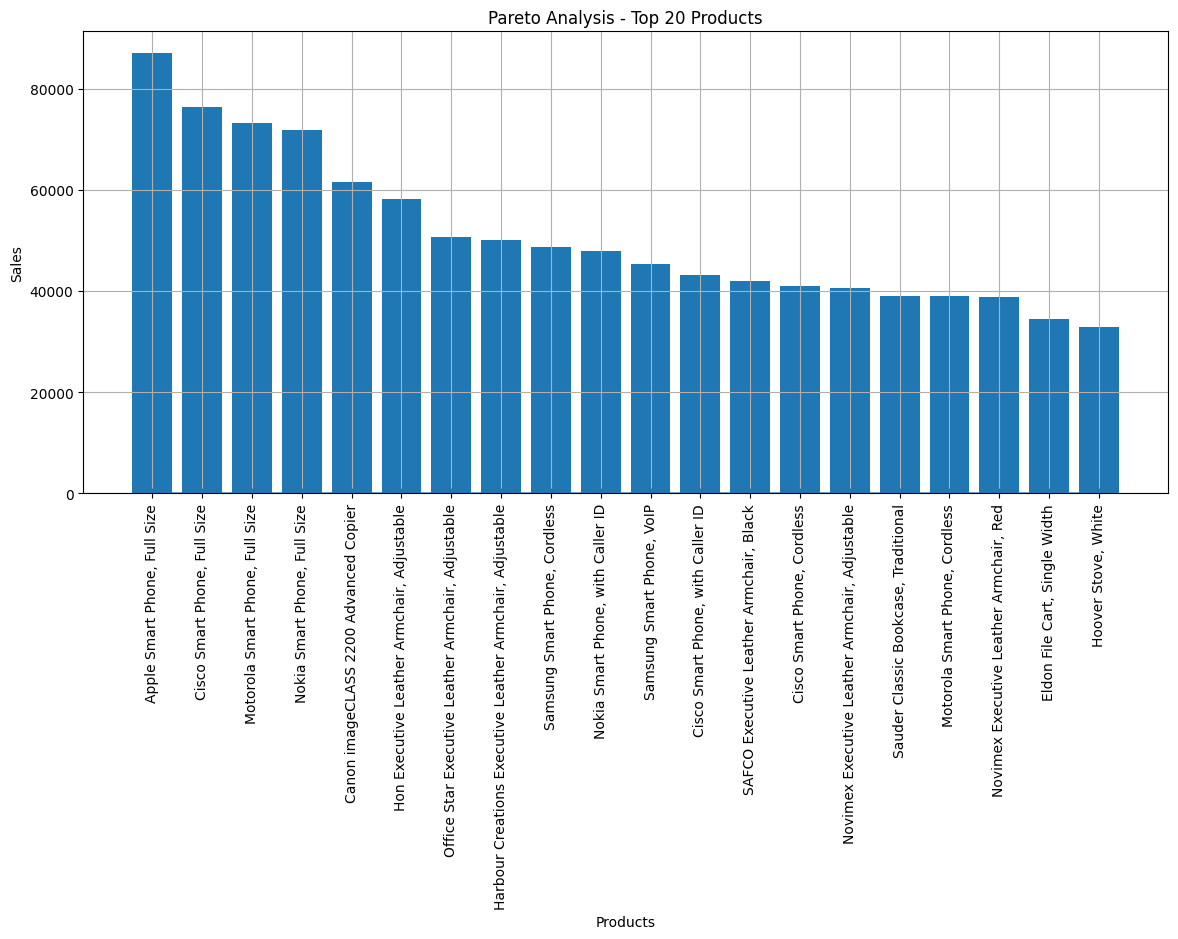

In [ ]:
plt.figure(figsize=(14,6))

plt.bar(
    pareto['Product Name'][:20],
    pareto['Sales'][:20]
)

plt.plot(
    pareto['Product Name'][:20],
    pareto['Cumulative Percentage'][:20],
    marker='o'
)

plt.xticks(rotation=90)

plt.title("Pareto Analysis - Top 20 Products")

plt.xlabel("Products")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

In [ ]:
# Who are our best customers?

top_customers = df.groupby('Customer Name').agg({
    'Sales':'sum',
    'Profit':'sum',
    'Order ID':'count'
})

top_customers.columns = [
    'Total Sales',
    'Total Profit',
    'Orders'
]

top_customers = top_customers.sort_values(
    'Total Sales',
    ascending=False
)

top_customers.head(20)

,Total Sales,Total Profit,Orders
Customer Name,,,
Tom Ashbrook,40489,6311.97910,80
Tamara Chand,37453,8672.89890,88
Greg Tran,35552,5214.13118,87
Christopher Conant,35187,5603.33370,73
Sean Miller,35170,-409.70634,50
Bart Watters,32315,3595.88590,96
Natalie Fritzler,31778,1542.82110,95
Fred Hopkins,30404,4609.29112,82
Jane Waco,30288,6265.84570,75


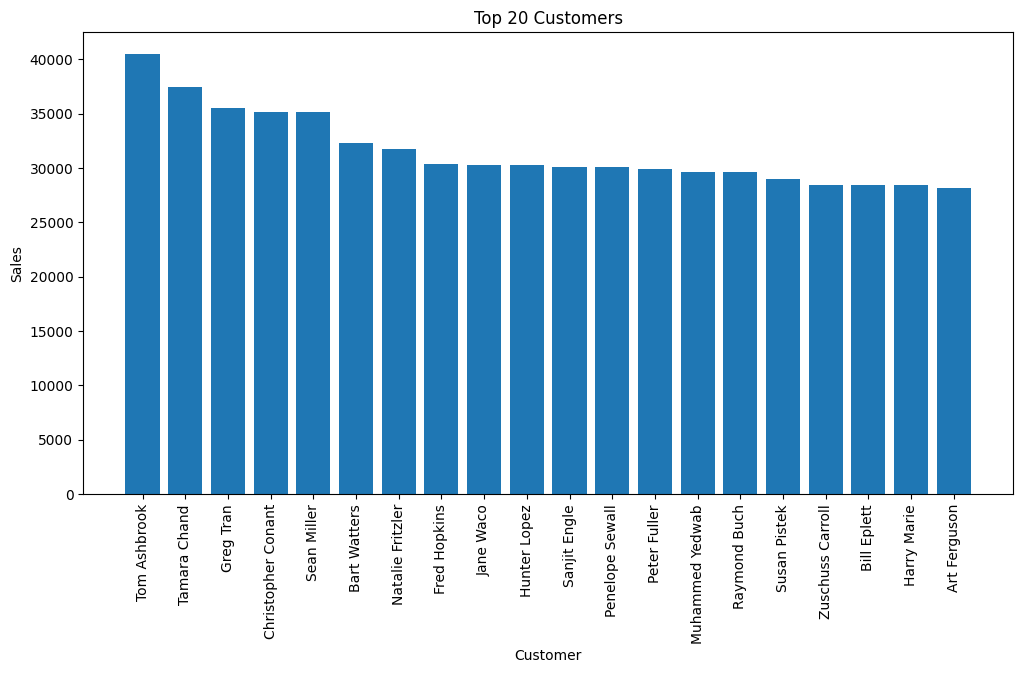

In [ ]:
top20 = top_customers.head(20)

plt.figure(figsize=(12,6))

plt.bar(
    top20.index,
    top20['Total Sales']
)

plt.xticks(rotation=90)

plt.title("Top 20 Customers")

plt.xlabel("Customer")

plt.ylabel("Sales")

plt.show()

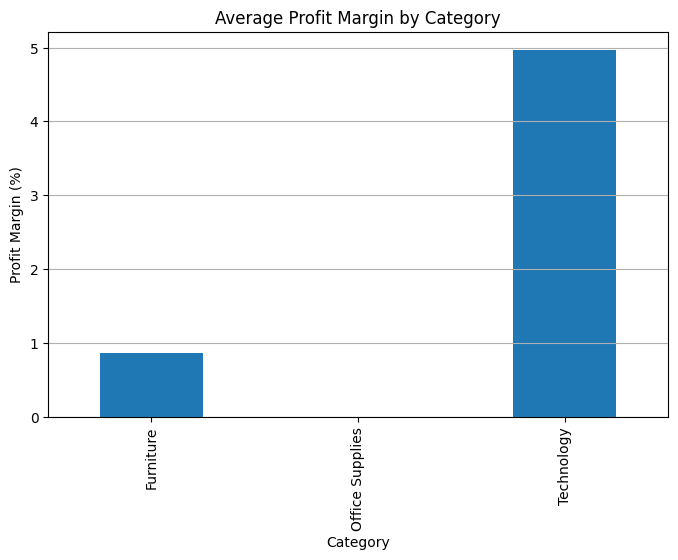

In [ ]:
# Analysis 3: Profit Margin Analysis

category_margin = df.groupby('Category')['Profit Margin'].mean()

plt.figure(figsize=(8,5))

category_margin.plot(kind='bar')

plt.title("Average Profit Margin by Category")

plt.ylabel("Profit Margin (%)")

plt.grid(axis='y')

plt.show()

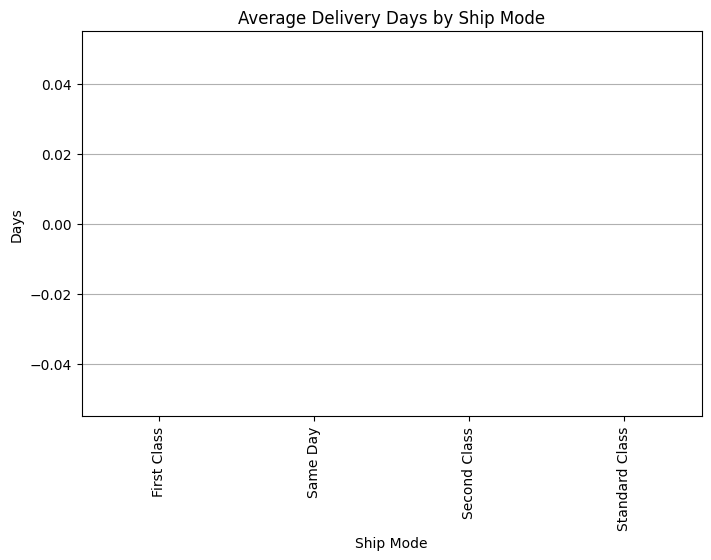

In [ ]:
#Analysis 4: Average Delivery Time by Ship Mode

delivery = df.groupby('Ship Mode')['Delivery Days'].mean()

plt.figure(figsize=(8,5))

delivery.plot(kind='bar')

plt.title("Average Delivery Days by Ship Mode")

plt.ylabel("Days")

plt.grid(axis='y')

plt.show()

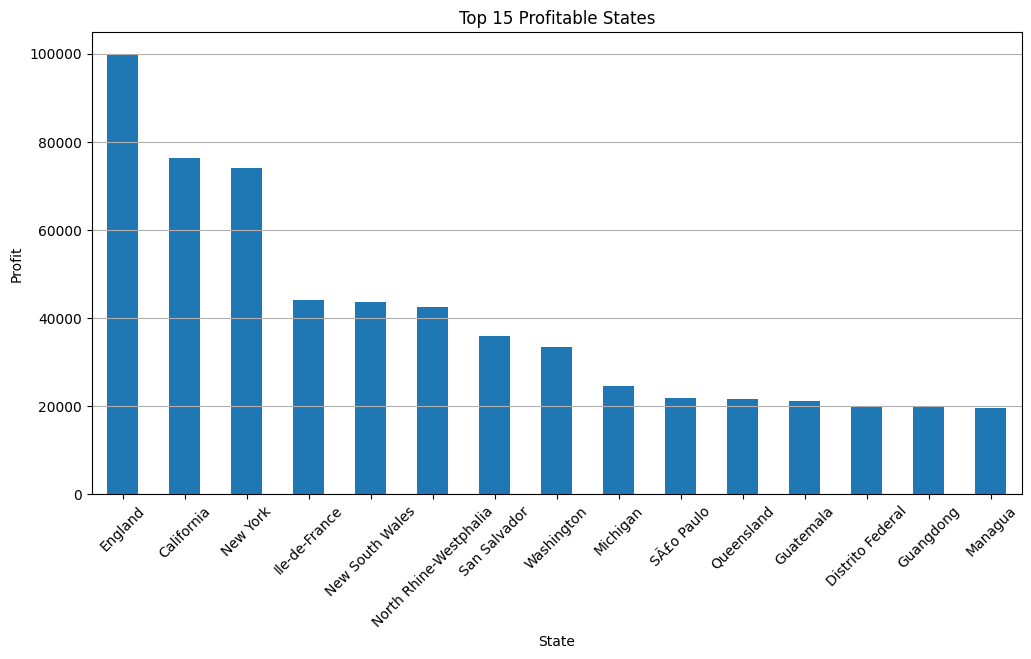

In [ ]:
#Analysis 5: Most Profitable States

state_profit = df.groupby('State')['Profit'].sum().sort_values(
    ascending=False
).head(15)

plt.figure(figsize=(12,6))

state_profit.plot(kind='bar')

plt.title("Top 15 Profitable States")

plt.ylabel("Profit")

plt.xticks(rotation=45)

plt.grid(axis='y')

plt.show()

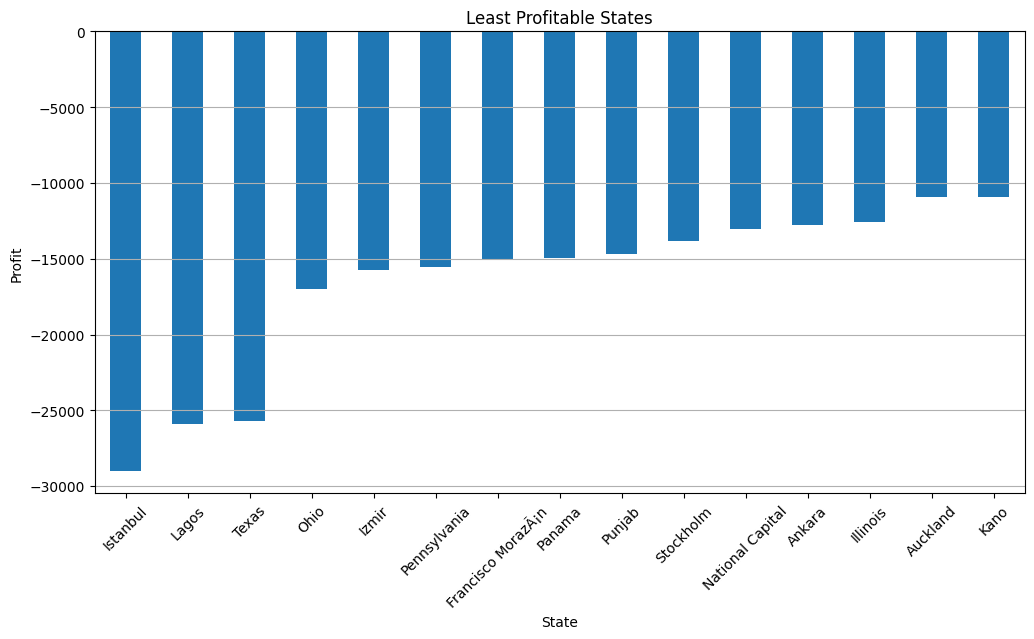

In [ ]:
# 📌 Analysis 6: Least Profitable States

loss_states = df.groupby('State')['Profit'].sum().sort_values().head(15)

plt.figure(figsize=(12,6))

loss_states.plot(kind='bar')

plt.title("Least Profitable States")

plt.ylabel("Profit")

plt.xticks(rotation=45)

plt.grid(axis='y')

plt.show()

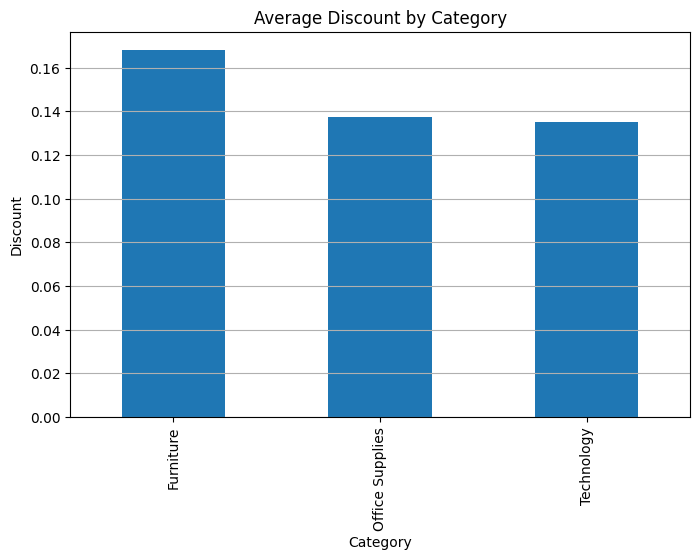

In [ ]:
#📌 Analysis 7: Average Discount by Category

discount = df.groupby('Category')['Discount'].mean()

plt.figure(figsize=(8,5))

discount.plot(kind='bar')

plt.title("Average Discount by Category")

plt.ylabel("Discount")

plt.grid(axis='y')

plt.show()

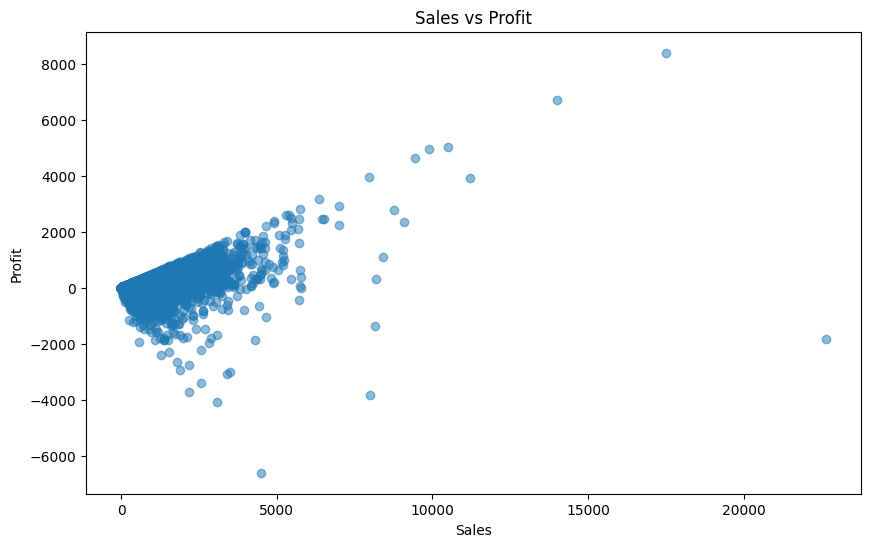

In [ ]:
#📌 Analysis 8: Sales vs Profit Relationship

plt.figure(figsize=(10,6))

plt.scatter(
    df['Sales'],
    df['Profit'],
    alpha=0.5
)

plt.title("Sales vs Profit")

plt.xlabel("Sales")

plt.ylabel("Profit")

plt.show()



In [ ]:
df .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 33 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Category        51290 non-null  object        
 1   City            51290 non-null  object        
 2   Country         51290 non-null  object        
 3   Customer ID     51290 non-null  object        
 4   Customer Name   51290 non-null  object        
 5   Discount        51290 non-null  float64       
 6   Market          51290 non-null  object        
 7   ji_lu-shu       51290 non-null  int64         
 8   Order Date      51290 non-null  datetime64[ns]
 9   Order ID        51290 non-null  object        
 10  Order Priority  51290 non-null  object        
 11  Product ID      51290 non-null  object        
 12  Product Name    51290 non-null  object        
 13  Profit          51290 non-null  float64       
 14  Quantity        51290 non-null  int64         
 15  Re

In [ ]:
monthly_sales = df.resample('ME', on='Order Date')['Sales'].sum()

monthly_sales.head()

,Sales
Order Date,
2026-08-31,12642905


In [ ]:
print(df['Order Date'].min())
print(df['Order Date'].max())

2026-08-04 00:00:00
2026-08-04 00:00:00


In [ ]:
df['Order Date'] = pd.to_datetime('today')

In [ ]:
df['Order Date'] = pd.Timestamp.today()

In [ ]:
from datetime import datetime
df['Order Date'] = datetime.now()

In [ ]:
import pandas as pd

df = pd.read_csv("Global Superstore.csv", encoding="latin1")

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [ ]:
print(df['Order Date'].min())
print(df['Order Date'].max())

2026-08-04 00:00:00
2026-08-04 00:00:00


In [ ]:
df[['Order Date', 'Ship Date']].head(10)

,Order Date,Ship Date
0,2026-08-04,2026-08-04
1,2026-08-04,2026-08-04
2,2026-08-04,2026-08-04
3,2026-08-04,2026-08-04
4,2026-08-04,2026-08-04
5,2026-08-04,2026-08-04
6,2026-08-04,2026-08-04
7,2026-08-04,2026-08-04
8,2026-08-04,2026-08-04
9,2026-08-04,2026-08-04


In [ ]:
df.columns

Index(['Category', 'City', 'Country', 'Customer ID', 'Customer Name',
       'Discount', 'Market', 'ji_lu-shu', 'Order Date', 'Order ID',
       'Order Priority', 'Product ID', 'Product Name', 'Profit', 'Quantity',
       'Region', 'Row ID', 'Sales', 'Segment', 'Ship Date', 'Ship Mode',
       'Shipping Cost', 'State', 'Sub-Category', 'Year', 'Market2', 'weeknum'],
      dtype='object')

In [ ]:
import os
print(os.listdir())

['.config', 'sample_data']


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Global Superstore.csv to Global Superstore.csv


In [ ]:
import pandas as pd

df = pd.read_csv("Global Superstore.csv", encoding="latin1")

In [ ]:
df[['Order Date', 'Ship Date']].head()

,Order Date,Ship Date
0,00:00.0,00:00.0
1,00:00.0,00:00.0
2,00:00.0,00:00.0
3,00:00.0,00:00.0
4,00:00.0,00:00.0


In [ ]:
df[['Order Date', 'Ship Date']].head()

,Order Date,Ship Date
0,00:00.0,00:00.0
1,00:00.0,00:00.0
2,00:00.0,00:00.0
3,00:00.0,00:00.0
4,00:00.0,00:00.0


In [ ]:
df.head()

,Category,City,Country,Customer ID,Customer Name,Discount,Market,ji_lu-shu,Order Date,Order ID,...,Sales,Segment,Ship Date,Ship Mode,Shipping Cost,State,Sub-Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,00:00.0,CA-2011-130813,...,19,Consumer,00:00.0,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,00:00.0,CA-2011-148614,...,19,Consumer,00:00.0,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,21,Consumer,00:00.0,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,111,Consumer,00:00.0,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,00:00.0,CA-2011-146969,...,6,Consumer,00:00.0,Standard Class,1.32,California,Paper,2011,North America,40


In [ ]:
df.dtypes

,0
Category,object
City,object
Country,object
Customer ID,object
Customer Name,object
Discount,float64
Market,object
ji_lu-shu,int64
Order Date,object
Order ID,object


In [ ]:
import pandas as pd
import numpy as np

# Create monthly dates from 2011 to 2014
date_range = pd.date_range(start='2011-01-01', end='2014-12-31', freq='ME')

print(date_range[:5])
print(len(date_range))

DatetimeIndex(['2011-01-31', '2011-02-28', '2011-03-31', '2011-04-30',
               '2011-05-31'],
              dtype='datetime64[ns]', freq='ME')
48


In [ ]:
# Total sales records
sales_values = df['Sales'].values

# Split sales into 48 monthly groups
monthly_groups = np.array_split(sales_values, 48)

# Calculate monthly sales totals
monthly_sales = pd.Series(
    [group.sum() for group in monthly_groups],
    index=date_range
)

monthly_sales.head()

,0
2011-01-31,129317
2011-02-28,137421
2011-03-31,186405
2011-04-30,127872
2011-05-31,186651


🚀 Phase 5: Time Series Forecasting

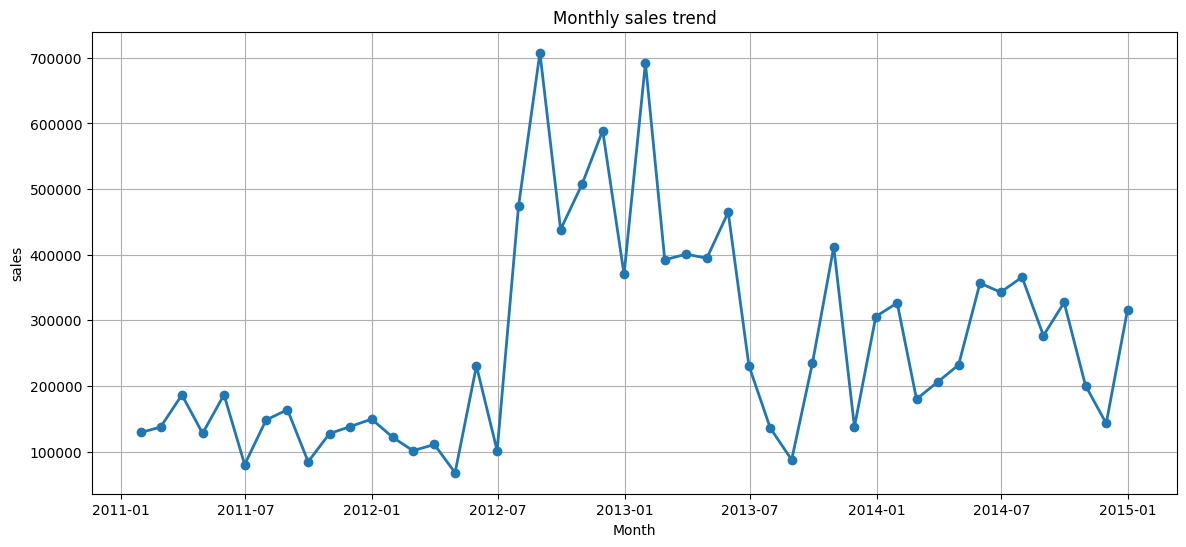

In [ ]:
#Visualize Monthly Sales
plt.figure(figsize=(14,6))
plt.plot(monthly_sales.index,monthly_sales.values,marker='o',linewidth=2)
plt.title("Monthly sales trend")
plt.xlabel("Month")
plt.ylabel("sales")
plt.grid(True)
plt.show()

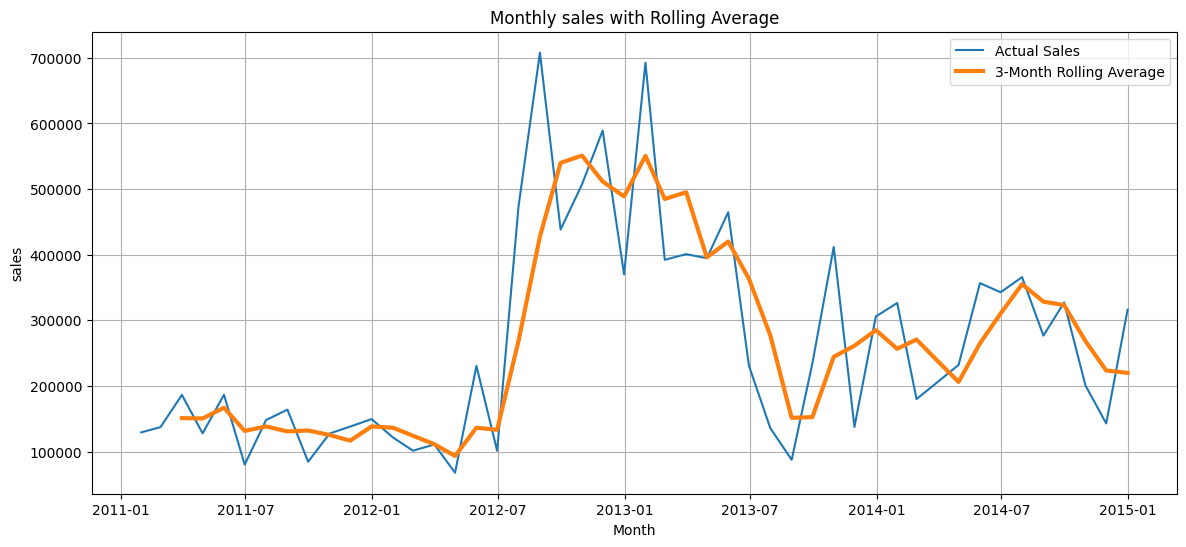

In [ ]:
rolling_mean=monthly_sales.rolling(window=3).mean()
plt.figure(figsize=(14,6))
plt.plot(monthly_sales.index,monthly_sales.values,label="Actual Sales")
plt.plot(rolling_mean.index,rolling_mean.values,linewidth=3,label="3-Month Rolling Average")
plt.title("Monthly sales with Rolling Average")
plt.xlabel("Month")
plt.ylabel("sales")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
!pip install statsmodels

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing


In [ ]:
#train the model from past data
model=ExponentialSmoothing(monthly_sales,trend='add',seasonal=None)
fit=model.fit()

In [ ]:
forecast=fit.forecast(12)
forecast

,0
2015-01-31,263962.503998
2015-02-28,266294.647318
2015-03-31,268626.790639
2015-04-30,270958.933960
2015-05-31,273291.077280
2015-06-30,275623.220601
2015-07-31,277955.363922
2015-08-31,280287.507242
2015-09-30,282619.650563
2015-10-31,284951.793884


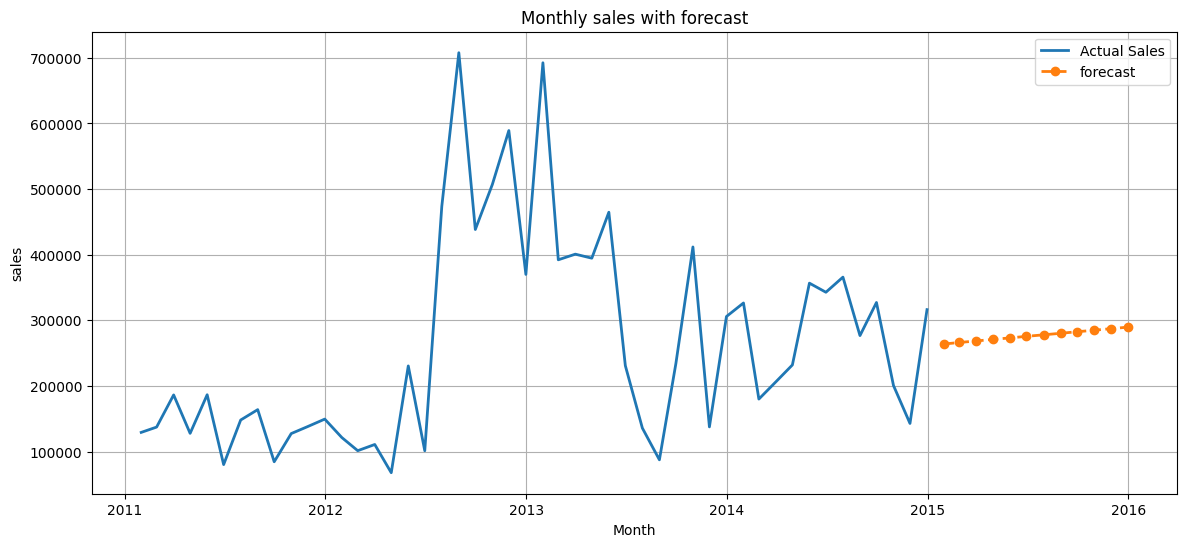

In [ ]:
#Visualize the forecast
plt.figure(figsize=(14,6))
plt.plot(monthly_sales.index,monthly_sales.values,label="Actual Sales",linewidth=2)
plt.plot(forecast.index,forecast.values,marker='o',linestyle='dashed',linewidth=2,label='forecast')
plt.title("Monthly sales with forecast")
plt.xlabel("Month")
plt.ylabel("sales")
plt.grid(True)
plt.legend()
plt.show()

# KPIs

In [ ]:
total_sales=df['Sales'].sum()

In [ ]:
total_profit=df['Profit'].sum()

In [ ]:
total_orders=df['Order ID'].nunique()

In [ ]:
total_customers=df['Customer ID'].nunique()

In [ ]:
# Total Sales
total_sales = df['Sales'].sum()

# Total Profit
total_profit = df['Profit'].sum()

# Total Orders
total_orders = df['Order ID'].nunique()

# Total Customers
total_customers = df['Customer ID'].nunique()

# Average Order Value
average_order_value = total_sales / total_orders

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Average Order Value:", round(average_order_value, 2))

Total Sales: 12642905
Total Profit: 1467457.2912800002
Total Orders: 25035
Total Customers: 4873
Average Order Value: 505.01


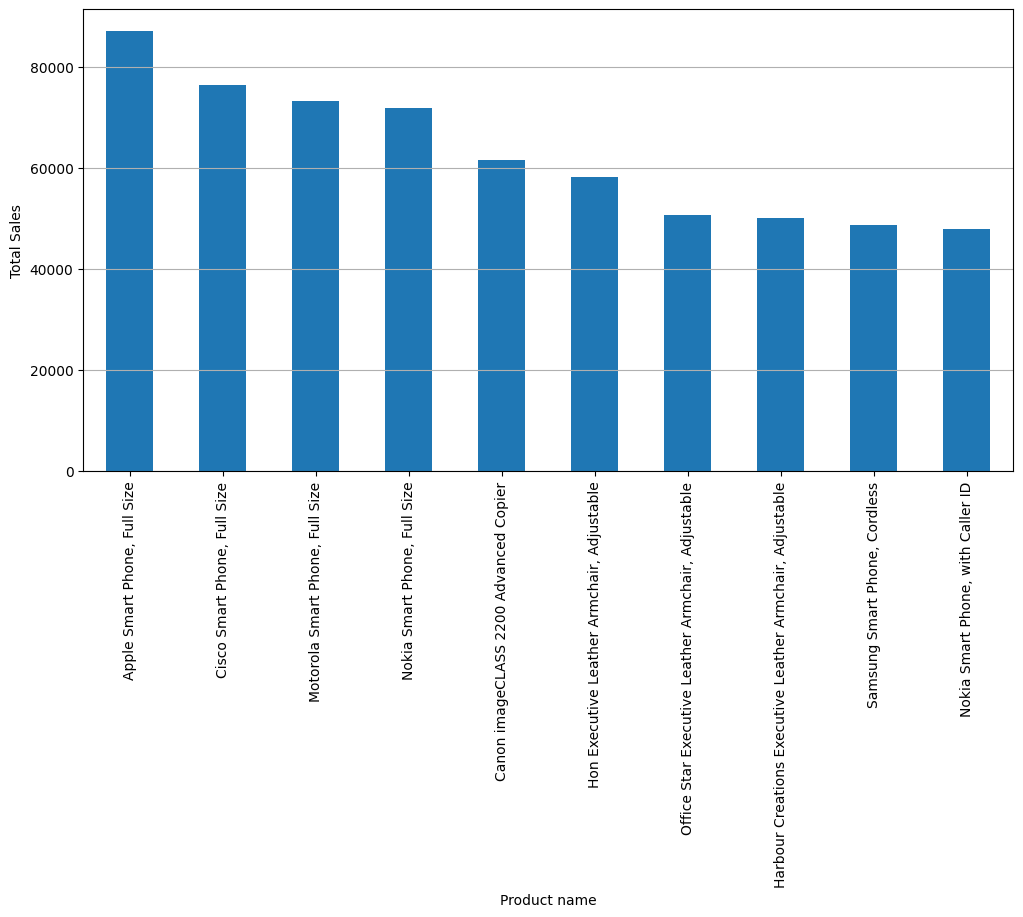

In [ ]:
#Top 10 Products by Sales

top_products=df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))

top_products.plot(kind='bar')
plt.xlabel("Product name")
plt.ylabel("Total Sales")
plt.xticks(rotation=90)
plt.grid(axis='y')
plt.show()


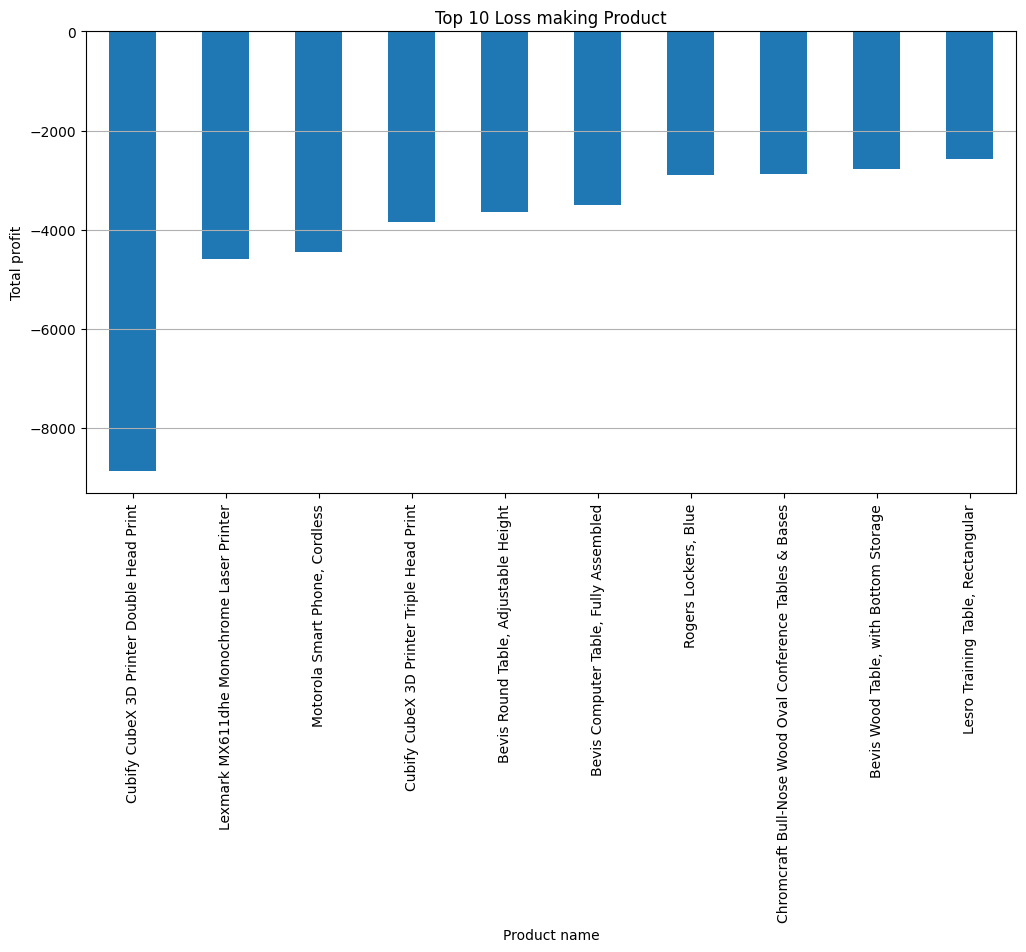

In [ ]:
#loss Making products

loss_products=df.groupby('Product Name')['Profit'].sum().sort_values().head(10)
plt.figure(figsize=(12,6))

loss_products.plot(kind='bar')
plt.title("Top 10 Loss making Product")
plt.xlabel("Product name")
plt.ylabel("Total profit")
plt.xticks(rotation=90)
plt.grid(axis='y')
plt.show()


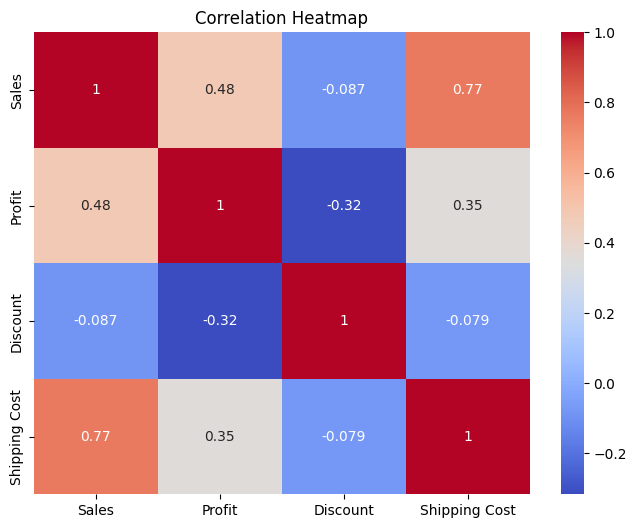

In [ ]:
#Correlation Heatmap

plt.figure(figsize=(8,6))
sns.heatmap(df[['Sales','Profit','Discount','Shipping Cost']].corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
plt.savefig("Sales_by_Category.png", dpi=300, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

In [ ]:
forecast_df = forecast.reset_index()
forecast_df.columns = ['Month', 'Forecast Sales']

forecast_df.to_csv("Sales_Forecast.csv", index=False)